# Burn severity in Rhodes, Greece (2023)

**Note:** This example is based on the _Introduction to Geospatial Raster and Vector Data with Python_ tutorial available [here](https://carpentries-incubator.github.io/geospatial-python/).

In [117]:
# PACKAGES

## Package list
pkgs <- c("rstac", "sf", "lubridate", "terra", "dplyr")

## Install missing packages
pkgs_installed <- pkgs %in% rownames(installed.packages())
if (any(pkgs_installed == FALSE)) install.packages(pkgs[!pkgs_installed])

## Load packages
invisible(lapply(pkgs, library, character.only = TRUE))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:terra’:

    intersect, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# SETTINGS

## Plotting options
options(repr.plot.width  =  12,
        repr.plot.height =   8,
        repr.plot.res    = 150)

In [27]:
# PARAMETERS

## STAC endpoint URL
cons_endpoint <- "https://earth-search.aws.element84.com/v1"

## Dataset collection ID
param_collection <- "sentinel-2-l2a"

## Path to the file defining the region-of-interest
param_roi_path <- paste0(getwd(), "/rhodes.gpkg")

## Target coordinate reference system code
param_crs_t <- "EPSG:32635"

## Start and end dates
param_date_start <- "2023-07-01"
param_date_end <- "2023-08-31"

## Pre- and post-fire dates
param_date_pre <- "2023-07-08"
param_date_post <- "2023-08-27"

## Cloud cover threshold
param_thresh_cloud <- 30

## Asset codes
param_bands <- c("nir08", "swir22")

## Path to the directory to save outputs
param_dir_out <- tempdir()
if (!dir.exists(param_dir_out)) dir.create(param_dir_out)

## Define the region-of-interest

In [151]:
# STAC Define RoI
# NaaVRE:
#  cell:
#   outputs:
#    - param_roi_wkt: String
#   params:
#    - param_roi_path: String
#    - param_dir_out: String
#   dependencies:
#    - name: sf
# ...

## Load packages
library(sf)

## Import RoI from external file
roi <- param_roi_path |>
  st_read(quiet = TRUE) |>
  st_as_sf()

## Project to target CRS
if (st_crs(roi)$proj4string != st_crs(param_crs_t)$proj4string) {
  roi <- st_transform(roi, crs = st_crs(4326))
}

## Output to file
roi_fn <- paste0(param_dir_out, "/roi.gpkg")
if (file.exists(roi_fn)) file.remove(roi_fn)
st_write(roi, roi_fn, quiet = TRUE, append = FALSE)

[1] TRUE

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 1, 16  (geometries, attributes)
 extent      : 561490.2, 611896.7, 3970534, 4035473  (xmin, xmax, ymin, ymax)
 coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
 names       : bbox_west bbox_south bbox_east bbox_north  place_id osm_type
 type        :     <num>      <num>     <num>      <num>     <num>    <chr>
 values      :     27.68      35.88     28.25      36.46 5.005e+07 relation
    osm_id   lat   lon class (and 6 more)
     <num> <num> <num> <chr>             
 4.526e+05 36.17 27.92 place             


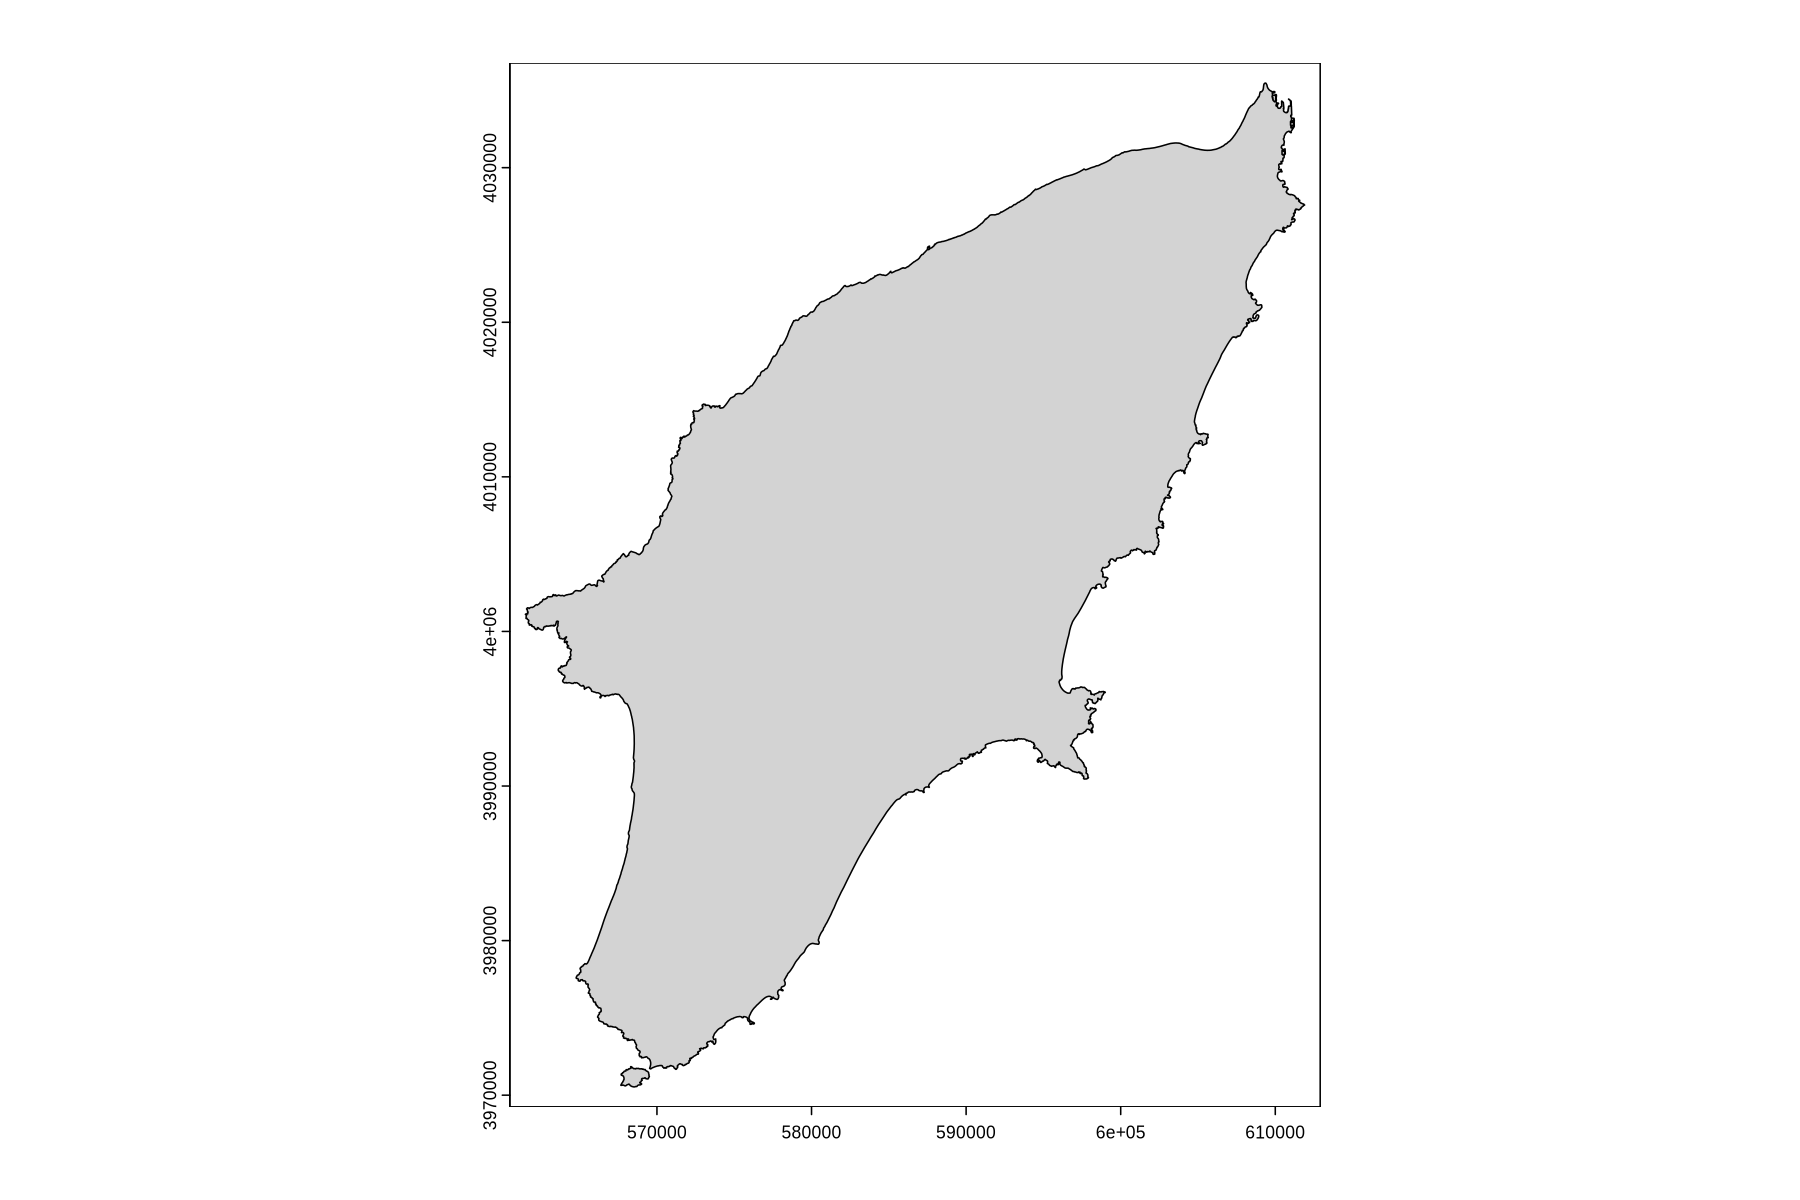

In [156]:
# Test if RoI was correctly created
roi_sv <- vect(roi) |>
    project("EPSG:32635")
print(roi_sv)
plot(roi_sv, col = "lightgray")

## Select and download images

In [46]:
# STAC Download Prefire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_pre: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_pre: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

## Load packages
library(sf)
library(rstac)

## Define a custom function to convert dates
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, limit = 100, start_date, end_date, target_date = NULL,
                          bbox = NULL, roi_path = NULL, thresh_cloud = NULL, asset_names = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start_date, end_date), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange,
                  limit       = limit)
    
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }

    ### (Sub)select and fetch items
    items <- post_request(search)
    if(!is.null(thresh_cloud)) {
        items <- post_request(search)
        suppressWarnings(items <- items_filter(items, properties$`eo:cloud_cover` < thresh_cloud))
    }
    items <- items_fetch(items, progress = FALSE)
    if(!is.null(asset_names)) {
        items <- assets_select(items, asset_names = asset_names)
    }
    if(!is.null(target_date)) {
        target_date <- date2rfc3339(target_date)
        items <- items_select(items, selection = which(items_datetime(items) == as.Date(target_date)))
    }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

## Select and download pre-fire images
dl_files_pre <- stac_download(endpoint     = cons_endpoint,
                              collection   = param_collection,
                              limit        = 100,
                              start        = param_date_start,
                              end          = param_date_end,
                              roi_path     = param_roi_path,
                              asset_names  = param_bands,
                              target_date  = param_date_pre,
                              out_path     = param_dir_out)

In [48]:
# List results
items_as_tibble(dl_files_pre)

constellation,created,datetime,earthsearch:boa_offset_applied,earthsearch:payload_id,earthsearch:s3_path,eo:cloud_cover,grid:code,instruments,mgrs:grid_square,⋯,s2:saturated_defective_pixel_percentage,s2:sequence,s2:snow_ice_percentage,s2:thin_cirrus_percentage,s2:unclassified_percentage,s2:vegetation_percentage,s2:water_percentage,updated,view:sun_azimuth,view:sun_elevation
<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
sentinel-2,2023-07-08T17:31:07.727Z,2023-07-08T09:00:35.241000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/e8620eebba2befdf91f58264cfd25877,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A,0.039288,MGRS-35SNV,msi,NV,⋯,0,0,0,0.000073,0.016608,1.552258,92.96231,2023-07-08T17:31:07.727Z,124.2712,69.20422
sentinel-2,2023-07-08T17:39:48.136Z,2023-07-08T09:00:20.745000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/81dbac5c25003af0bdb52f5450199e0d,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A,0.029514,MGRS-35SNA,msi,NA,⋯,0,0,0,0.000402,0.079342,10.064361,74.28475,2023-07-08T17:39:48.136Z,126.0868,68.64885
sentinel-2,2023-07-08T17:25:06.447Z,2023-07-08T09:00:17.434000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/ac38f8969beaec4e7156fff4695a26ba,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A,1.655831,MGRS-35SPA,msi,PA,⋯,0,0,0,0.027568,0.230888,21.613187,61.46569,2023-07-08T17:25:06.447Z,128.1200,69.36429


In [44]:
# STAC Download Postfire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_post: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_post: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

## Load packages
library(sf)
library(rstac)

## Define a custom function to convert dates
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, limit = 100, start_date, end_date, target_date = NULL,
                          bbox = NULL, roi_path = NULL, thresh_cloud = NULL, asset_names = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start_date, end_date), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange,
                  limit       = limit)
    
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }

    ### (Sub)select and fetch items
    items <- post_request(search)
    if(!is.null(thresh_cloud)) {
        items <- post_request(search)
        suppressWarnings(items <- items_filter(items, properties$`eo:cloud_cover` < thresh_cloud))
    }
    items <- items_fetch(items, progress = FALSE)
    if(!is.null(asset_names)) {
        items <- assets_select(items, asset_names = asset_names)
    }
    if(!is.null(target_date)) {
        target_date <- date2rfc3339(target_date)
        items <- items_select(items, selection = which(items_datetime(items) == as.Date(target_date)))
    }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

## Select and download pre-fire images
dl_files_post <- stac_download(endpoint     = cons_endpoint,
                               collection   = param_collection,
                               limit        = 100,
                               start        = param_date_start,
                               end          = param_date_end,
                               roi_path     = param_roi_path,
                               asset_names  = param_bands,
                               target_date  = param_date_post,
                               out_path     = param_dir_out)

In [45]:
# List results
items_as_tibble(dl_files_post)

constellation,created,datetime,earthsearch:boa_offset_applied,earthsearch:payload_id,earthsearch:s3_path,eo:cloud_cover,grid:code,instruments,mgrs:grid_square,⋯,s2:saturated_defective_pixel_percentage,s2:sequence,s2:snow_ice_percentage,s2:thin_cirrus_percentage,s2:unclassified_percentage,s2:vegetation_percentage,s2:water_percentage,updated,view:sun_azimuth,view:sun_elevation
<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
sentinel-2,2023-08-27T18:20:46.953Z,2023-08-27T09:00:35.818000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/91e74a5a119449f848db45267e9403c5,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A,3.800320,MGRS-35SNV,msi,NV,⋯,0,0,0.0e+00,0.001546,0.138651,0.572359,90.16079,2023-08-27T18:20:46.953Z,143.5569,59.82155
sentinel-2,2023-08-27T18:15:43.106Z,2023-08-27T09:00:21.327000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/af0287974aaa3fbb037c6a7632f72742,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A,0.955362,MGRS-35SNA,msi,NA,⋯,0,0,2.3e-05,0.000325,0.198216,6.073786,74.25906,2023-08-27T18:15:43.106Z,144.3635,59.06665
sentinel-2,2023-08-27T18:21:54.510Z,2023-08-27T09:00:18.016000Z,TRUE,roda-sentinel2/workflow-sentinel2-to-stac/463c11671a1450db1a2f09fc387f863d,s3://sentinel-cogs/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A,3.467271,MGRS-35SPA,msi,PA,⋯,0,0,1.7e-05,0.001974,0.354624,17.984529,61.10564,2023-08-27T18:21:54.510Z,146.2436,59.58160


In [102]:
# Check all downloaded files
dl_files <- list.files(path = param_dir_out, pattern = "*.tif", full.names = TRUE, recursive = TRUE)
dl_files

[1] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
 [2] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
 [3] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
 [4] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
 [5] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
 [6] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
 [7] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
 [8] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
 [9] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[10] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"
[11] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B12.tif"
[12] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B8A.tif"

## Image preprocessing

### Mosaic (merge) different tiles

The three scenes/tiles have to be merged into one image for each of pre- and post-fire:

In [125]:
## Build table with all properties
dl_files_sep <- strsplit(dl_files, split = "/")
dl_files_df <- cbind(dl_files, as.data.frame(do.call(rbind, lapply(dl_files_sep, rbind))))
names(dl_files_df) <- c("path", "root", "dir", "subdir", "collection", "zone", "area", "tile", "year", "month", "name", "band")
dl_files_df

path,root,dir,subdir,collection,zone,area,tile,year,month,name,band
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NA,2023,7,S2A_35SNA_20230708_0_L2A,B12.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NA,2023,7,S2A_35SNA_20230708_0_L2A,B8A.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NA,2023,8,S2A_35SNA_20230827_0_L2A,B12.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NA,2023,8,S2A_35SNA_20230827_0_L2A,B8A.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NV,2023,7,S2A_35SNV_20230708_0_L2A,B12.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NV,2023,7,S2A_35SNV_20230708_0_L2A,B8A.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NV,2023,8,S2A_35SNV_20230827_0_L2A,B12.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,NV,2023,8,S2A_35SNV_20230827_0_L2A,B8A.tif
/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif,,tmp,Rtmp2KMpcy,sentinel-s2-l2a-cogs,35,S,PA,2023,7,S2A_35SPA_20230708_0_L2A,B12.tif


In [127]:
## Apply grouping to pre-fire images
pre_list <- filter(dl_files_df, month == "7")
print(pre_list$path)

[1] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
[2] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
[3] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
[4] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
[5] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[6] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"


In [128]:
## Apply grouping to post-fire images
post_list <- filter(dl_files_df, month == "8")
print(post_list$path)

[1] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
[2] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
[3] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
[4] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
[5] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B12.tif"
[6] "/tmp/Rtmp2KMpcy/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B8A.tif"


In [134]:
## Merge tiles for pre-fire images
s2_pre_path <- paste0(param_dir_out, "/s2_pre.tif")
merge(x = rast(filter(pre_list, tile == "NA")$path),
      y = rast(filter(pre_list, tile == "NV")$path),
      z = rast(filter(pre_list, tile == "PA")$path),
      filename = s2_pre_path, overwrite = TRUE)
gc()

class       : SpatRaster 
dimensions  : 10491, 10491, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 499980, 709800, 3890220, 4100040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
source      : s2_pre.tif 
names       :   B12,   B8A 
min values  :     1,     1 
max values  : 15430, 17384 

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1771950,94.7,3342958,178.6,3342958,178.6
Vcells,2895019,22.1,8388608,64.0,8383899,64.0


In [135]:
## Merge tiles for post-fire images
s2_post_path <- paste0(param_dir_out, "/s2_post.tif")
merge(x = rast(filter(post_list, tile == "NA")$path),
      y = rast(filter(post_list, tile == "NV")$path),
      z = rast(filter(post_list, tile == "PA")$path),
      filename = s2_post_path, overwrite = TRUE)
gc()

class       : SpatRaster 
dimensions  : 10491, 10491, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 499980, 709800, 3890220, 4100040  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
source      : s2_post.tif 
names       :   B12,   B8A 
min values  :     1,     1 
max values  : 15852, 19933 

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1771663,94.7,3342958,178.6,3342958,178.6
Vcells,2894959,22.1,8388608,64.0,8383899,64.0


### Crop images to RoI

In [157]:
## Crop pre-fire image
s2_pre_path_c <- paste0(param_dir_out, "/s2_pre_c.tif")
crop(x = rast(s2_pre_path), y = roi_sv, mask = TRUE,
     filename = s2_pre_path_c, overwrite = TRUE)
gc()

class       : SpatRaster 
dimensions  : 3247, 2520, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 561500, 611900, 3970540, 4035480  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
source      : s2_pre_c.tif 
varname     : s2_pre 
names       :  B12,  B8A 
min values  :   44,    1 
max values  : 9805, 9635 

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1789294,95.6,3342958,178.6,3342958,178.6
Vcells,2933282,22.4,8388608,64.0,8383899,64.0


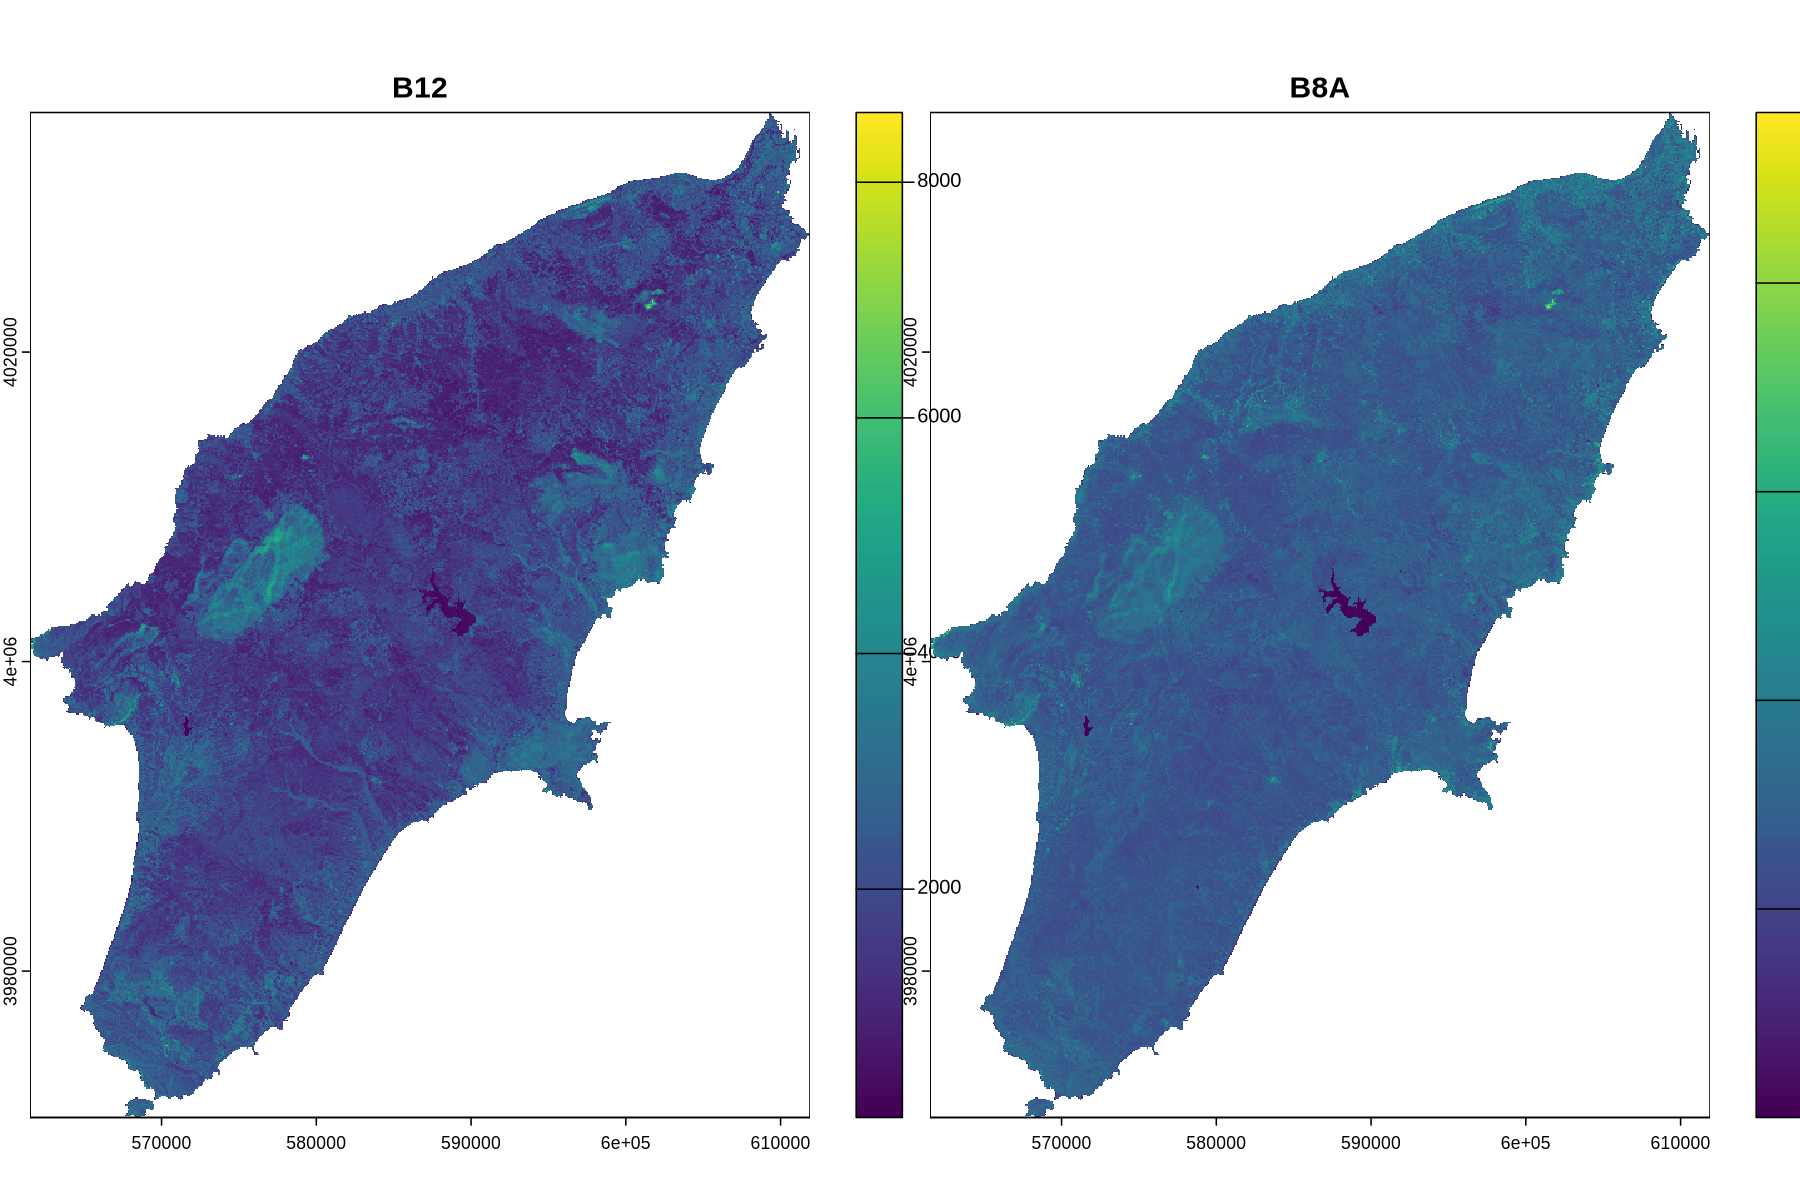

In [159]:
plot(rast(s2_pre_path_c))

In [160]:
## Crop post-fire image
s2_post_path_c <- paste0(param_dir_out, "/s2_post_c.tif")
crop(x = rast(s2_post_path), y = roi_sv, mask = TRUE,
     filename = s2_post_path_c, overwrite = TRUE)
gc()

class       : SpatRaster 
dimensions  : 3247, 2520, 2  (nrow, ncol, nlyr)
resolution  : 20, 20  (x, y)
extent      : 561500, 611900, 3970540, 4035480  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 35N (EPSG:32635) 
source      : s2_post_c.tif 
varname     : s2_post 
names       :   B12,   B8A 
min values  :     1,     1 
max values  : 11877, 16514 

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1807567,96.6,3342958,178.6,3342958,178.6
Vcells,2976826,22.8,10146329,77.5,10129670,77.3


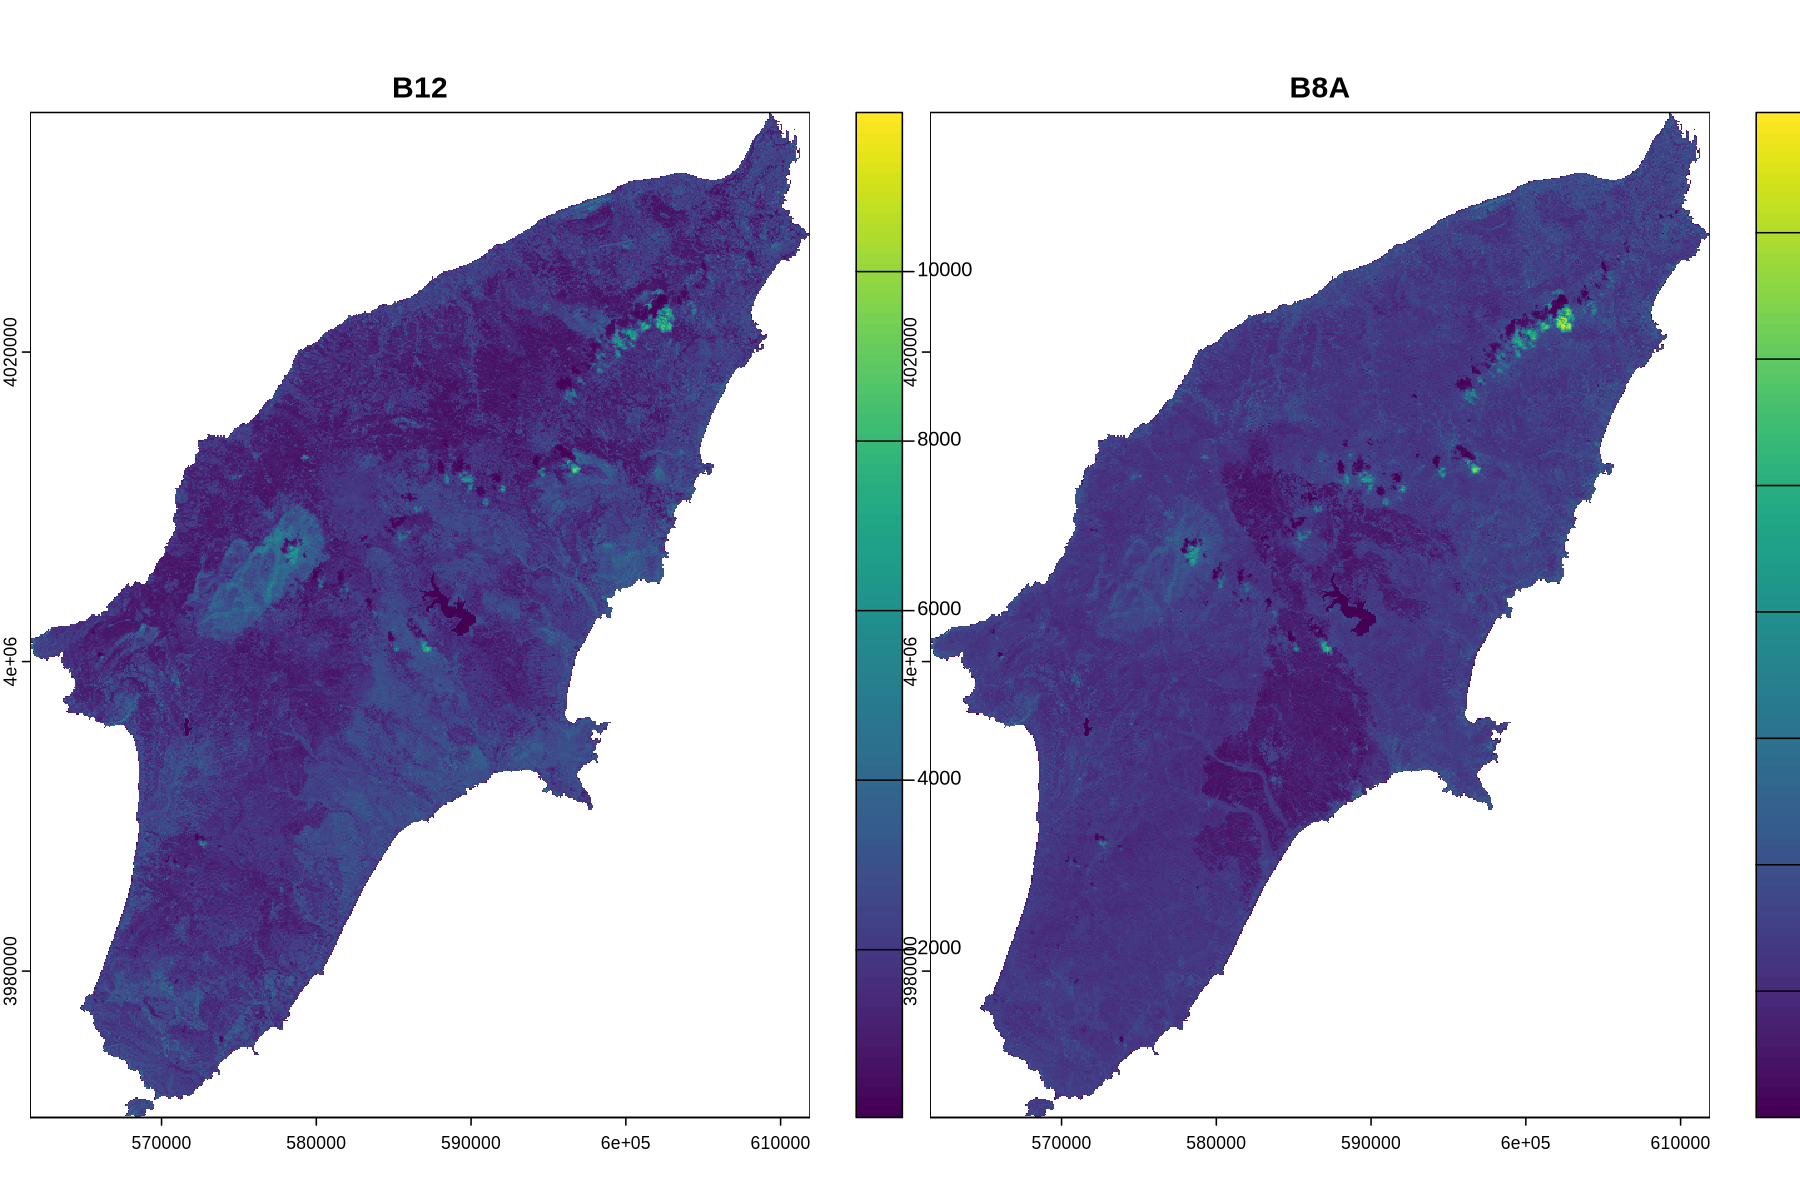

In [161]:
plot(rast(s2_post_path_c))

## Calculate burn severity

In [ ]:
## Compute Normalised Burn Ratio (NBR)
s2_pre_path_nbr <- paste0(param_dir_out, "/s2_pre_nbr.tif")
lapp(x = rast(s2_pre_path_c),
     fun = function(B12, B8A) { ((B12 - B8A) / (B12 + B8A)) },
     usenames = TRUE, cores = 4,
     filename = s2_pre_path_nbr, overwrite = TRUE)
gc()